# 02 · Retrieval-Augmented Generation (RAG)

**Lecture slides 21–37.** An LLM's knowledge is frozen at its pre-training data, its context window is limited, it gets distracted by irrelevant text, and you pay per token. RAG addresses all four: **retrieve** only the relevant pieces of a knowledge base, **augment** the prompt with them, then **generate**.

## Step 1 · Candidate retrieval with vector search

**Vector search** (a.k.a. semantic or embedding search) encodes the query and every document as a dense vector with an embedding model, then ranks documents by **cosine similarity** to the query. Because the embedding captures meaning rather than exact words, a query about a "pet that can talk like a person" can match a document saying a bird "mimics human speech", even though they share no key words.

Below we chunk and embed a tiny knowledge base, search it, measure retrieval quality with standard ranking metrics, and finally run the full retrieve → augment → generate pipeline. (In notebook 04 the same retriever becomes a *tool* an agent decides when to call.)

This section needs a **local embedding model**: [`sentence-transformers/all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2) from Hugging Face, one of the smallest widely-used sentence embedding models (~90MB, 384-dim vectors). It downloads automatically the first time it's used and runs entirely offline afterward — no server to start. The generation step at the end uses a chat model, either local through Ollama or a cloud API (you choose below).

We load it with the plain `transformers` library (`AutoTokenizer` + `AutoModel`, with mean pooling done by hand) rather than the `sentence-transformers` wrapper package. That wrapper's recent releases hard-import an optional audio/video decoding dependency (`torchcodec`) at load time — even though we only need text — and `torchcodec` requires a matching FFmpeg install that not every machine has. Mean-pooling the token embeddings ourselves is exactly what that wrapper does internally, so results are equivalent, without the extra system dependency.

In [1]:
# %pip install -q numpy transformers torch matplotlib

## Prerequisite · Build the knowledge base: chunking

Real documents are too long to embed or stuff into a prompt whole, so they are split into **chunks** first. The key hyperparameters are the **chunk size** and the **overlap** between consecutive chunks (so a fact that straddles a boundary still appears intact in one chunk), plus the embedding size of the model you index them with.

In [2]:
from typing import Callable, Dict, List, Tuple

TEDDY_HISTORY = (
    "The teddy bear is named after Theodore Roosevelt, the 26th president of the United States. "
    "In 1902, on a hunting trip in Mississippi, Roosevelt refused to shoot a bear that had been tied to a tree. "
    "A political cartoon by Clifford Berryman made the story famous. "
    "Inspired by the cartoon, Brooklyn shop owner Morris Michtom created a stuffed toy bear and called it Teddy's bear. "
    "Around the same time in Germany, Richard Steiff designed a jointed toy bear for the Steiff company, "
    "and it became a hit at the Leipzig toy fair in 1903."
)


def chunk_text(text: str, chunk_size: int = 30, overlap: int = 10) -> List[str]:
    """Split text into chunks of `chunk_size` words, each sharing `overlap` words with the previous one."""
    words = text.split()
    step = chunk_size - overlap
    return [" ".join(words[start:start + chunk_size]) for start in range(0, max(len(words) - overlap, 1), step)]


for i, chunk in enumerate(chunk_text(TEDDY_HISTORY), start=1):
    print(f"chunk {i}: {chunk}\n")

chunk 1: The teddy bear is named after Theodore Roosevelt, the 26th president of the United States. In 1902, on a hunting trip in Mississippi, Roosevelt refused to shoot a bear that

chunk 2: trip in Mississippi, Roosevelt refused to shoot a bear that had been tied to a tree. A political cartoon by Clifford Berryman made the story famous. Inspired by the cartoon,

chunk 3: Clifford Berryman made the story famous. Inspired by the cartoon, Brooklyn shop owner Morris Michtom created a stuffed toy bear and called it Teddy's bear. Around the same time in

chunk 4: and called it Teddy's bear. Around the same time in Germany, Richard Steiff designed a jointed toy bear for the Steiff company, and it became a hit at the Leipzig

chunk 5: Steiff company, and it became a hit at the Leipzig toy fair in 1903.



**Try it:** change `chunk_size` and `overlap`. Too small and chunks lose context; too large and each chunk mixes several topics (and costs more tokens in the prompt).

To keep the results easy to read, the rest of this notebook uses a knowledge base that is already chunk-sized: one sentence per document.

## A tiny knowledge base

Eight short documents about pets, and two example queries: one that shares words with the document it's aimed at (`d5`), and one that only paraphrases its target (`d4`).

In [3]:
# ── The knowledge base RAG will retrieve from ─────────────────────────────────
CORPUS: List[Dict[str, str]] = [
    {"id": "d1", "text": "The Siberian Husky is a medium-sized working dog breed originally bred for sled pulling in cold climates."},
    {"id": "d2", "text": "Persian cats have long, thick fur and a calm, gentle temperament, making them popular indoor pets."},
    {"id": "d3", "text": "Goldfish are freshwater fish commonly kept in home aquariums; they can live over 10 years with proper care."},
    {"id": "d4", "text": "African Grey Parrots are known for their exceptional ability to mimic human speech and solve problems."},
    {"id": "d5", "text": "Bengal cats are a hybrid breed resulting from crossing domestic cats with the Asian leopard cat."},
    {"id": "d6", "text": "Golden Retrievers are friendly, intelligent dogs often used as guide dogs and family companions."},
    {"id": "d7", "text": "Bearded dragons are docile reptiles native to Australia, popular as low-maintenance terrarium pets."},
    {"id": "d8", "text": "Canaries are small songbirds prized for their bright colors and melodic singing ability."},
]
CORPUS_BY_ID: Dict[str, str] = {doc["id"]: doc["text"] for doc in CORPUS}

# One query that shares words with its target document (d5), one that only paraphrases its target (d4)
EXAMPLE_QUERIES = ["Bengal cat leopard hybrid breed", "a pet that can talk like a person"]

for doc in CORPUS:
    print(f"{doc['id']}: {doc['text']}")

d1: The Siberian Husky is a medium-sized working dog breed originally bred for sled pulling in cold climates.
d2: Persian cats have long, thick fur and a calm, gentle temperament, making them popular indoor pets.
d3: Goldfish are freshwater fish commonly kept in home aquariums; they can live over 10 years with proper care.
d4: African Grey Parrots are known for their exceptional ability to mimic human speech and solve problems.
d5: Bengal cats are a hybrid breed resulting from crossing domestic cats with the Asian leopard cat.
d6: Golden Retrievers are friendly, intelligent dogs often used as guide dogs and family companions.
d7: Bearded dragons are docile reptiles native to Australia, popular as low-maintenance terrarium pets.
d8: Canaries are small songbirds prized for their bright colors and melodic singing ability.


## Embedding and searching

Every document is embedded once (cached in `CORPUS_EMBEDDINGS`) with a small local Hugging Face model; a query is embedded on the fly and ranked against the corpus by cosine similarity. Embeddings come from mean-pooling the model's per-token outputs — the standard way to turn a transformer's token-level output into one fixed-size vector per sentence.

In [4]:
# ── Vector retriever: local Hugging Face embeddings + cosine similarity ───────
import numpy as np
import torch
from transformers import AutoModel, AutoTokenizer

EMBED_MODEL_ID = "sentence-transformers/all-MiniLM-L6-v2"
embed_tokenizer = AutoTokenizer.from_pretrained(EMBED_MODEL_ID)
embed_model = AutoModel.from_pretrained(EMBED_MODEL_ID)
embed_model.eval()


def embed_texts(texts: List[str]) -> np.ndarray:
    """Mean-pool token embeddings (masking out padding) into one L2-normalized vector per text."""
    encoded = embed_tokenizer(texts, padding=True, truncation=True, return_tensors="pt")
    with torch.no_grad():
        token_embeddings = embed_model(**encoded)[0]
    mask = encoded["attention_mask"].unsqueeze(-1).float()
    pooled = (token_embeddings * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
    return torch.nn.functional.normalize(pooled, p=2, dim=1).numpy()


def _cosine_similarity(query_vec: np.ndarray, doc_vecs: np.ndarray) -> np.ndarray:
    # embed_texts already L2-normalizes, so the dot product IS the cosine similarity
    return doc_vecs @ query_vec


# Embed the whole corpus once and reuse it for every query below
CORPUS_EMBEDDINGS = embed_texts([doc["text"] for doc in CORPUS])


def vector_search(query: str, top_k: int = len(CORPUS)) -> List[Tuple[str, float]]:
    """Rank every doc_id by cosine similarity between its embedding and the query's; returns (doc_id, score) sorted best-first."""
    query_vec = embed_texts([query])[0]
    similarities = _cosine_similarity(query_vec, CORPUS_EMBEDDINGS)
    ranked = sorted(zip((doc["id"] for doc in CORPUS), similarities), key=lambda x: x[1], reverse=True)
    return ranked[:top_k]


for query in EXAMPLE_QUERIES:
    print(f"Query: {query!r}")
    for doc_id, score in vector_search(query, top_k=3):
        print(f"  {doc_id}  score={score:.3f}  {CORPUS_BY_ID[doc_id]}")
    print()

/Users/rinabuoy/miniforge3/envs/LLMs/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7791.89it/s]

Query: 'Bengal cat leopard hybrid breed'
  d5  score=0.794  Bengal cats are a hybrid breed resulting from crossing domestic cats with the Asian leopard cat.
  d2  score=0.363  Persian cats have long, thick fur and a calm, gentle temperament, making them popular indoor pets.
  d1  score=0.267  The Siberian Husky is a medium-sized working dog breed originally bred for sled pulling in cold climates.

Query: 'a pet that can talk like a person'
  d2  score=0.387  Persian cats have long, thick fur and a calm, gentle temperament, making them popular indoor pets.
  d4  score=0.330  African Grey Parrots are known for their exceptional ability to mimic human speech and solve problems.
  d6  score=0.319  Golden Retrievers are friendly, intelligent dogs often used as guide dogs and family companions.



## Seeing it: similarity of every document to each query

The chart plots the cosine similarity between each query and all eight documents (`*` marks the document the query is aimed at). For the paraphrased query, the parrot (`d4`) scores high without sharing a single key word. But it isn't the clear winner: the Persian cat (`d2`, "calm, gentle temperament… indoor pets") scores close to it. Embeddings capture *topic* as well as meaning, so similarity scores are a noisy signal. That's why the ranking step and the evaluation below matter.

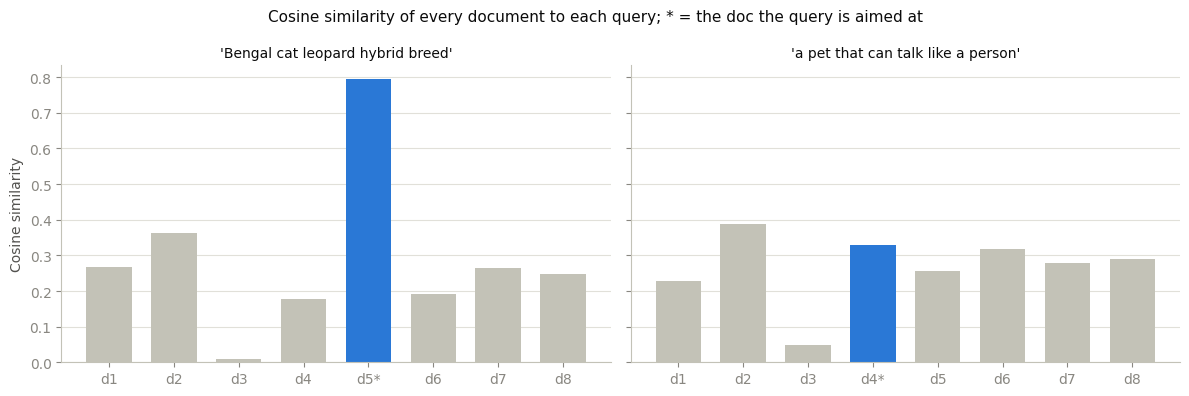

In [5]:
import matplotlib.pyplot as plt

DOC_IDS = [doc["id"] for doc in CORPUS]


def plot_similarities(query: str, target_doc_id: str, ax: plt.Axes) -> None:
    scores = dict(vector_search(query))
    values = [scores[doc_id] for doc_id in DOC_IDS]
    colors = ["#2a78d6" if doc_id == target_doc_id else "#c3c2b7" for doc_id in DOC_IDS]
    ax.bar(range(len(DOC_IDS)), values, color=colors, width=0.7)
    ax.set_xticks(range(len(DOC_IDS)))
    ax.set_xticklabels([f"{d}*" if d == target_doc_id else d for d in DOC_IDS], color="#52514e")
    ax.set_title(f"{query!r}", fontsize=10, color="#0b0b0b")
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color("#c3c2b7")
    ax.tick_params(colors="#898781")


fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plot_similarities(EXAMPLE_QUERIES[0], "d5", axes[0])
plot_similarities(EXAMPLE_QUERIES[1], "d4", axes[1])
axes[0].set_ylabel("Cosine similarity", color="#52514e")
fig.suptitle("Cosine similarity of every document to each query; * = the doc the query is aimed at", fontsize=11, color="#0b0b0b")
fig.tight_layout()
plt.show()

## Step 2 · Ranking, and quantifying retrieval performance

Retrieval usually has two stages: **candidate retrieval** (cheap, over the whole knowledge base, tuned for *recall*) then **ranking** (a more expensive scorer over the few candidates, tuned for *precision*). To know whether a retriever is any good, we need a small set of test queries with known relevant documents, and ranking metrics:

| Metric | Question it answers |
|---|---|
| **Precision@k** | Of the top *k* results, what fraction are relevant? |
| **RR@k** (reciprocal rank) | 1 / rank of the *first* relevant result (0 if none in the top *k*). Averaged over queries → **MRR**. |
| **NDCG@k** | Are the *most* relevant documents near the top? Rewards graded relevance, discounted by log of the rank, normalized so a perfect ranking = 1. |

In [6]:
import math

# Test queries with graded relevance labels: {doc_id: relevance} (2 = highly relevant, 1 = partially)
EVAL_SET: List[Tuple[str, Dict[str, int]]] = [
    ("Bengal cat leopard hybrid breed", {"d5": 2}),
    ("a pet that can talk like a person", {"d4": 2}),
    ("which dog breed pulls sleds in the snow?", {"d1": 2}),
    ("a fluffy indoor cat with a relaxed personality", {"d2": 2}),
    ("an easy pet that lives in a glass tank", {"d7": 2, "d3": 1}),
    ("which birds make good pets?", {"d4": 2, "d8": 2}),
    ("dogs that help blind people", {"d6": 2}),
    ("cat breeds", {"d2": 2, "d5": 2}),
]


def precision_at_k(ranked: List[str], relevant: Dict[str, int], k: int) -> float:
    return sum(doc_id in relevant for doc_id in ranked[:k]) / k


def reciprocal_rank_at_k(ranked: List[str], relevant: Dict[str, int], k: int) -> float:
    for rank, doc_id in enumerate(ranked[:k], start=1):
        if doc_id in relevant:
            return 1.0 / rank
    return 0.0


def ndcg_at_k(ranked: List[str], relevant: Dict[str, int], k: int) -> float:
    dcg = sum(relevant.get(doc_id, 0) / math.log2(rank + 1) for rank, doc_id in enumerate(ranked[:k], start=1))
    ideal = sorted(relevant.values(), reverse=True)[:k]
    idcg = sum(rel / math.log2(rank + 1) for rank, rel in enumerate(ideal, start=1))
    return dcg / idcg if idcg > 0 else 0.0


K = 3
print(f"{'Query':48} {'top-3':14} {'P@3':>5} {'RR@3':>5} {'NDCG@3':>7}")
scores = {"p": [], "rr": [], "ndcg": []}
for query, relevant in EVAL_SET:
    ranked = [doc_id for doc_id, _ in vector_search(query)]
    p, rr, ndcg = precision_at_k(ranked, relevant, K), reciprocal_rank_at_k(ranked, relevant, K), ndcg_at_k(ranked, relevant, K)
    scores["p"].append(p)
    scores["rr"].append(rr)
    scores["ndcg"].append(ndcg)
    print(f"{query:48} {' '.join(ranked[:K]):14} {p:5.2f} {rr:5.2f} {ndcg:7.2f}")

mean = {m: sum(v) / len(v) for m, v in scores.items()}
print(f"{'MEAN':48} {'':14} {mean['p']:5.2f} {mean['rr']:5.2f} {mean['ndcg']:7.2f}")

Query                                            top-3            P@3  RR@3  NDCG@3
Bengal cat leopard hybrid breed                  d5 d2 d1        0.33  1.00    1.00
a pet that can talk like a person                d2 d4 d6        0.33  0.50    0.63
which dog breed pulls sleds in the snow?         d1 d6 d8        0.33  1.00    1.00
a fluffy indoor cat with a relaxed personality   d2 d5 d7        0.33  1.00    1.00
an easy pet that lives in a glass tank           d2 d7 d3        0.67  0.50    0.67
which birds make good pets?                      d8 d4 d2        0.67  1.00    1.00
dogs that help blind people                      d6 d4 d8        0.33  1.00    1.00
cat breeds                                       d2 d5 d1        0.67  1.00    1.00
MEAN                                                             0.46  0.88    0.91


The per-query rows show *where* the retriever fails, which a single average hides. Note also that P@3 can never reach 1.0 here: most queries have only one relevant document, so at most 1 of the top 3 can be relevant. That's why RR and NDCG are usually more informative on small labeled sets.

**Try it:** add your own queries to `EVAL_SET`, such as paraphrases, exact rare names or product codes (embeddings often struggle with these), and see which ones fail.

## Steps 2 & 3 · Augment the prompt, then generate

Now the full pipeline: retrieve the top chunks, paste them into the prompt with numbered markers, and ask the LLM to answer *only* from them. To make the point clearly we use a knowledge base the model **cannot** know from pre-training — the internal FAQ of a fictional shop.

### Choose your LLM backend

Set `BACKEND` below: `"ollama"` runs a model **locally** through [Ollama](https://ollama.com) (free and private; run `ollama pull gemma4:e2b-mlx` first), while `"api"` calls any **OpenAI-compatible cloud API**: OpenAI, Google Gemini, Groq, OpenRouter and many more. Everything after this cell is identical for both, because `llm.chat()` in [`llm_client.py`](llm_client.py) returns the same response shape either way.

For `"api"`, set the environment variables `LLM_API_KEY`, `LLM_API_MODEL` and (for providers other than OpenAI) `LLM_API_BASE_URL` before starting Jupyter, or pass them directly: `llm.configure("api", model="...", base_url="https://...", api_key="...")`. If the key is missing you'll be asked for it.

In [7]:
# %pip install -q ollama openai
import llm_client as llm

BACKEND = "ollama"  # "ollama" (local) or "api" (OpenAI-compatible cloud API)

llm.configure(BACKEND)
LLM_MODEL_ID = llm.current_model()
print(llm.describe())

Backend: Ollama (local)  |  model: gemma4:e2b-mlx


In [8]:
from rag_utils import VectorRetriever

# A fictional shop — none of this is in any model's training data
SHOP_FAQ: List[Dict[str, str]] = [
    {"id": "f1", "text": "Teddy's Toy Shop is open Tuesday to Sunday, 10:00 to 19:00. It is closed on Mondays."},
    {"id": "f2", "text": "Returns: any bear can be returned within 45 days of purchase. A receipt is required for a cash refund; without one we offer store credit."},
    {"id": "f3", "text": "The Honey Points loyalty program gives 1 point per dollar spent. 100 Honey Points can be redeemed for a free mini bear."},
    {"id": "f4", "text": "The Bear Hospital repairs torn seams and loose eyes for free on bears bought at our shop; other bears cost $8 per repair."},
    {"id": "f5", "text": "Gift wrapping is free during December and costs $3 the rest of the year."},
    {"id": "f6", "text": "Our best-selling bear is Captain Honeypaw, a 40 cm bear with a sailor hat, priced at $34."},
    {"id": "f7", "text": "Online orders ship within 2 business days. Shipping is free for orders over $50."},
    {"id": "f8", "text": "Build-a-Bear workshops for children run every Saturday at 14:00 and must be booked in advance."},
]
faq_retriever = VectorRetriever(SHOP_FAQ)

question = "Can I return a teddy bear after 30 days if I lost the receipt?"

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9993.14it/s]

In [9]:
# Without retrieval: the model can only guess
response = llm.chat(model=LLM_MODEL_ID, messages=[{"role": "user", "content": question}])
print(response.message.content)

I cannot give you a definitive answer because **return policies vary significantly depending on the specific store or retailer** where you bought the teddy bear.

To find out if you can return the item after 30 days without a receipt, you need to check the official policy of the store where you purchased it.

**Here is what you should do:**

1. **Check the Store's Return Policy:** Look for the store's website or customer service page. They will specify their rules regarding returns, exchanges, and the requirements for proof of purchase (receipts).
2. **Contact Customer Service:** If you cannot find the policy online, call or visit the store directly. They will be able to tell you exactly what documentation (like an ID or credit card information) they require to process a return.

**General Retail Rules:**

* **Most stores require a receipt** to process a refund or exchange, especially if the return is outside of a specific, short window (like 30 days).
* **Without a receipt, returns ar

In [10]:
# 1. Retrieve
results = faq_retriever.vector_search(question, top_k=3)
context = "\n".join(f"[{i}] {faq_retriever.by_id[doc_id]}" for i, (doc_id, _) in enumerate(results, start=1))

# 2. Augment
augmented_prompt = (
    "Answer the question using ONLY the context below. Cite sources with their [n] markers. "
    "If the context does not contain the answer, say you don't know.\n\n"
    f"Context:\n{context}\n\nQuestion: {question}"
)
print(augmented_prompt)

Answer the question using ONLY the context below. Cite sources with their [n] markers. If the context does not contain the answer, say you don't know.

Context:
[1] Returns: any bear can be returned within 45 days of purchase. A receipt is required for a cash refund; without one we offer store credit.
[2] Teddy's Toy Shop is open Tuesday to Sunday, 10:00 to 19:00. It is closed on Mondays.
[3] Our best-selling bear is Captain Honeypaw, a 40 cm bear with a sailor hat, priced at $34.

Question: Can I return a teddy bear after 30 days if I lost the receipt?


In [11]:
# 3. Generate
response = llm.chat(model=LLM_MODEL_ID, messages=[{"role": "user", "content": augmented_prompt}])
print(response.message.content)
print(f"\n(prompt tokens: {response.prompt_eval_count})")

Any bear can be returned within 45 days of purchase [1]. A receipt is required for a cash refund; without one, store credit is offered [1].

(prompt tokens: 175)


Why not just paste the *whole* knowledge base into every prompt? For 8 sentences you could — but real knowledge bases have millions of chunks. Pricing is per token, context windows are finite, and irrelevant text distracts the model. Compare the prompt size:

In [12]:
everything = "\n".join(f"[{i}] {doc['text']}" for i, doc in enumerate(SHOP_FAQ, start=1))
response = llm.chat(
    model=LLM_MODEL_ID,
    messages=[{"role": "user", "content": augmented_prompt.replace(context, everything)}],
)
print(f"prompt tokens with the whole knowledge base: {response.prompt_eval_count}")

prompt tokens with the whole knowledge base: 309


## Key takeaways

- RAG = **retrieve** relevant chunks → **augment** the prompt → **generate**. It gives the model knowledge it never saw in pre-training, with sources it can cite.
- The knowledge base is built by **chunking** documents (chunk size, overlap) and embedding each chunk.
- **Vector search** embeds the query too and ranks chunks by **cosine similarity**, so it matches meaning rather than exact words, but similarity scores are noisy.
- Measure retrievers with **Precision@k**, **RR@k / MRR** and **NDCG@k** on a labeled query set before trusting them.